# 02 - Portfolio Optimization

Solve for the Global Minimum Variance (GMV) portfolio, the Maximum Sharpe Ratio (MSR) portfolio, and trace the efficient frontier.

In [1]:
import sys, os
sys.path.insert(0, '../src')
import yaml
import pandas as pd
import numpy as np

from data_loader import compute_monthly_returns, compute_stats
from optimization import gmv_portfolio, efficient_frontier, max_sharpe_portfolio, portfolio_performance
from visualization import plot_efficient_frontier

In [2]:
with open('../configs/tickers.yaml') as f:
    tickers = yaml.safe_load(f)['tickers']
with open('../configs/params.yaml') as f:
    params = yaml.safe_load(f)

prices = pd.read_csv('../data/stock_prices.csv', index_col=0, parse_dates=True)
monthly_returns = compute_monthly_returns(prices[tickers])
mean_returns, cov_matrix = compute_stats(monthly_returns)

mean_arr = mean_returns.values
cov_arr = cov_matrix.values

## Global Minimum Variance portfolio

In [3]:
gmv_w = gmv_portfolio(cov_arr)
gmv_ret, gmv_vol = portfolio_performance(gmv_w, mean_arr, cov_arr)

print(f'GMV expected return: {gmv_ret:.2%}')
print(f'GMV volatility: {gmv_vol:.2%}')
pd.Series(gmv_w, index=tickers).sort_values(ascending=False).round(4)

GMV expected return: 12.90%
GMV volatility: 11.14%


JNJ      0.2966
PG       0.2211
AMZN     0.1411
XOM      0.1245
KO       0.1162
GOOGL    0.0539
MSFT     0.0315
UNH      0.0129
JPM      0.0022
DIS     -0.0000
AAPL    -0.0000
V       -0.0000
CAT     -0.0000
HD      -0.0000
META    -0.0000
dtype: float64

## Maximum Sharpe Ratio portfolio

In [4]:
msr_w, msr_ret, msr_vol, msr_sharpe = max_sharpe_portfolio(mean_arr, cov_arr, params['risk_free_rate'])

print(f'MSR expected return: {msr_ret:.2%}')
print(f'MSR volatility: {msr_vol:.2%}')
print(f'MSR Sharpe ratio: {msr_sharpe:.2f}')
pd.Series(msr_w, index=tickers).sort_values(ascending=False).round(4)

MSR expected return: 26.26%
MSR volatility: 15.60%
MSR Sharpe ratio: 1.39


XOM      0.4014
GOOGL    0.2919
META     0.1480
KO       0.1181
JPM      0.0350
AAPL     0.0055
AMZN     0.0000
DIS      0.0000
HD       0.0000
MSFT     0.0000
CAT      0.0000
UNH      0.0000
V        0.0000
JNJ     -0.0000
PG      -0.0000
dtype: float64

## Efficient frontier

Saved plot to ../results/efficient_frontier.png


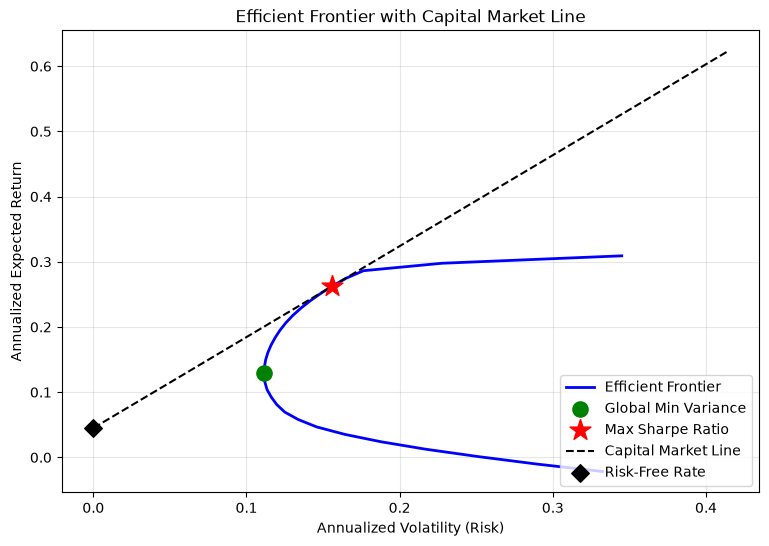

In [5]:
frontier_returns, frontier_vols, frontier_weights = efficient_frontier(
    mean_arr, cov_arr, n_points=params['n_frontier_points']
)

fig = plot_efficient_frontier(
    frontier_returns, frontier_vols,
    (gmv_vol, gmv_ret), (msr_vol, msr_ret),
    params['risk_free_rate'],
    save_path='../results/efficient_frontier.png'
)

In [6]:
import pandas as pd
weights_df = pd.DataFrame({'ticker': tickers, 'GMV_weight': gmv_w, 'MSR_weight': msr_w})
weights_df.to_csv('../results/portfolio_weights.csv', index=False)
weights_df.round(4)

,ticker,GMV_weight,MSR_weight
0,AAPL,-0.0000,0.0055
1,MSFT,0.0315,0.0000
2,GOOGL,0.0539,0.2919
3,AMZN,0.1411,0.0000
4,META,-0.0000,0.1480
5,JPM,0.0022,0.0350
6,JNJ,0.2966,-0.0000
7,PG,0.2211,-0.0000
8,XOM,0.1245,0.4014
9,V,-0.0000,0.0000
